In [ ]:
!unzip "/content/drive/MyDrive/AL and ML/Worksheet4/devnagari digit.zip" -d /content/devnagari

Archive:  /content/drive/MyDrive/AL and ML/Worksheet4/devnagari digit.zip
replace /content/devnagari/DevanagariHandwrittenDigitDataset/Test/digit_0/103277.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

print(len(os.listdir("/content/devnagari/DevanagariHandwrittenDigitDataset/Train")))

10


Task 1: Data Preparation

1. Import Libraries

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

2. Load Dataset (Your Devanagari Data)

In [ ]:
def load_devnagari_data(folder_path):
    images = []
    labels = []
    # class_names should be digit_0, digit_1... digit_9
    class_names = sorted(os.listdir(folder_path))

    for label_idx, class_name in enumerate(class_names):
        dir_path = os.path.join(folder_path, class_name)
        if not os.path.isdir(dir_path): continue

        for filename in os.listdir(dir_path):
            img_path = os.path.join(dir_path, filename)
            # Load, grayscale, resize, and normalize
            img = Image.open(img_path).convert("L").resize((28, 28))
            images.append(np.array(img) / 255.0)
            labels.append(label_idx)

    return np.array(images), np.array(labels)

In [ ]:
x_train_raw, y_train_raw = load_devnagari_data('/content/devnagari/DevanagariHandwrittenDigitDataset/Train')
x_test_raw, y_test_raw = load_devnagari_data('/content/devnagari/DevanagariHandwrittenDigitDataset/Test')

In [ ]:
x_train = x_train_raw.reshape(-1, 28, 28, 1)
x_test = x_test_raw.reshape(-1, 28, 28, 1)

In [ ]:
# One-hot encode labels
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

print(f"Data Loaded: Train {x_train.shape}, Test {x_test.shape}")

Data Loaded: Train (17000, 28, 28, 1), Test (3000, 28, 28, 1)


Tasks 2 & 3: Build and Compile the Model

In [61]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(256, activation='sigmoid'),
    layers.Dense(10, activation='softmax')   # Output
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Used because we one-hot encoded
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Tasks 4 & 5: Train and Evaluate

ADD ModelCheckpoint

In [63]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

In [64]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Task 5: Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2703 - loss: 2.0035

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4743 - loss: 1.6368 - val_accuracy: 0.0000e+00 - val_loss: 7.3163
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8235 - loss: 0.5169 - val_accuracy: 0.0000e+00 - val_loss: 8.6020
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9154 - loss: 0.2850 - val_accuracy: 0.0000e+00 - val_loss: 9.1170
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9452 - loss: 0.1926 - val_accuracy: 0.0000e+00 - val_loss: 9.5091
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9587 - loss: 0.1468 - val_accuracy: 0.0000e+00 - val_loss: 9.9876
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9678 - loss: 0.1177 - val_accuracy: 0.0000e+00 - val_loss: 10.2026

Final Test Accuracy: 63.80%


Task 6: Save and Load

In [65]:
# Save
model.save('devnagari_fcn_model.h5')
print("Model saved as devnagari_fcn_model.h5")

# Load and Verify
loaded_model = models.load_model('devnagari_fcn_model.h5')
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded Model Accuracy: {acc * 100:.2f}%")

Model saved as devnagari_fcn_model.h5
Loaded Model Accuracy: 63.80%


Task 7: Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Prediction: 0 | Actual: 0


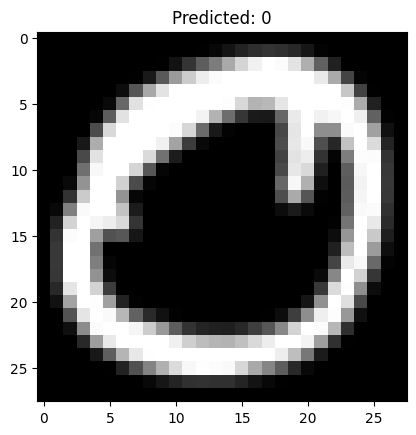

In [66]:
# Make predictions
predictions = loaded_model.predict(x_test)

# Logic: Get the index of the highest probability
predicted_label = np.argmax(predictions[0])
true_label = np.argmax(y_test[0])

print(f"Prediction: {predicted_label} | Actual: {true_label}")

# Visual deliverable
plt.imshow(x_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.show()

Visualizing Training Progress

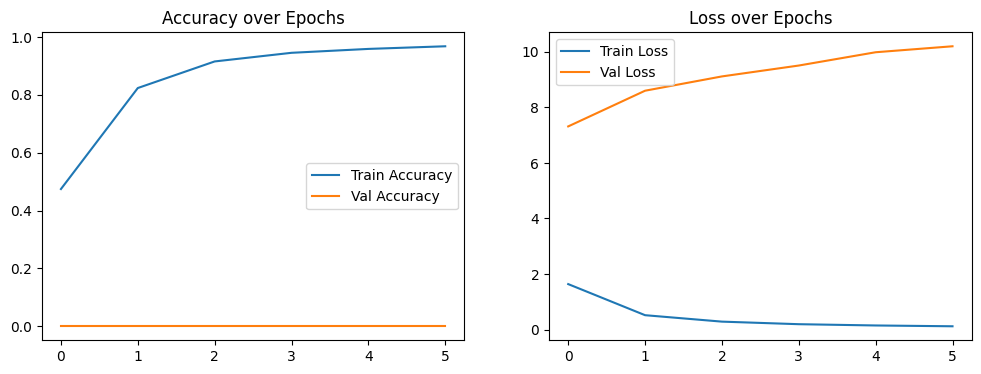

In [67]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()